# Объявление библиотек

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

## Перевод BGR→RGB

In [2]:
def bgr2rgb(img):
    if img.ndim != 3 or img.shape[2] != 3: # проверка, что у изображения ровно три измерения (высота, ширина, каналы), а так же что число каналов 3
        raise ValueError("Требуется цветное изображение (height,width,channels)")
    rgb_img = img.copy()
    rgb_img[:,:,0], rgb_img[:,:,2] = img[:,:,2].copy(), img[:,:,0].copy() # меняем порядок каналов 2,1,0
    return rgb_img

# 1. Фильтры 

## 1.1 Медианный фильтр

In [3]:
def median_filter(img, ksize=3): # ksize может быть только нечетным
    pad = ksize // 2 # считаем количество «отступа» по краям - это половина размера окна. для окна 3х3 pad=1 и это значит, что добавляем 
    #с каждой стороны по 1 пикселю
    padded = np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode='edge') # добавляем рамки к изображению по h, w, c
    # mode='edge' означает, что рамка заполняется значениями из ближайшего пикселя на границе (чтобы не было чёрной окантовки)
    rows, cols, channels = img.shape # сохранение/извлечение размеров исходного изображения
    out = np.zeros_like(img) # создаем выходное изображение "out" того же размера и типа, что и входное, заполненное нулями 
    # сюда будут записываться отфильтрованные значения

    for i in range(rows): # цикл по строкам (по координате i) всех пикселей исходного изображения
        for j in range(cols): # цикл по столбцам (по координате j)
            for c in range(channels): # цикл по каналам цвета
                window = padded[i:i+ksize, j:j+ksize] # выделяется «окно» (размером ksize × ksize из дополненного изображения) вокруг 
                # текущего пикселя по строкам от (i до i + ksize), столбцам (от j до j + ksize) и по текущему каналу c. pad обеспечивает размер окна всегда нужного значения
                out[i, j, c] = np.median(window[:, :, c]) # вычисляется медиана для каждого канала всех пикселей в этом окне и результат 
                # записывается в соответствующий пиксель и канал выходного изображения
    return out.astype(np.uint8) # возвращает новое изображение out, к которому по всем каналам и во всех точках применён медианный фильтр.

## Загрузка изображения

In [4]:
img_bgr = cv2.imread('cat1.png')
if img_bgr is None:
    print("Не удалось загрузить изображение")
    

## Использование медианного фильтра

In [5]:
# Применяем медианный фильтр
filtered_3x3 = median_filter(img_bgr, 3)  # Медианный фильтр 3x3
filtered_5x5 = median_filter(img_bgr, 5)  # Медианный фильтр 5x5

# Конвертация в RGB для отображения
img_rgb = bgr2rgb(img_bgr)
filtered_3x3_rgb = bgr2rgb(filtered_3x3)
filtered_5x5_rgb = bgr2rgb(filtered_5x5)

# Разделение каналов для оригинала и блюров
image_noize = img_rgb        # Оригинал (добавлен шум соль и перец)
image_blur3 = filtered_3x3_rgb  # После медианного фильтра 3x3
image_blur5 = filtered_5x5_rgb  # После медианного фильтра 5x5

#cv2.split() — функция OpenCV для разделения многоканального изображения на отдельные каналы.
r_noize, g_noize, b_noize = cv2.split(image_noize)
r_blur3, g_blur3, b_blur3 = cv2.split(image_blur3)
r_blur5, g_blur5, b_blur5 = cv2.split(image_blur5)



## Результат 

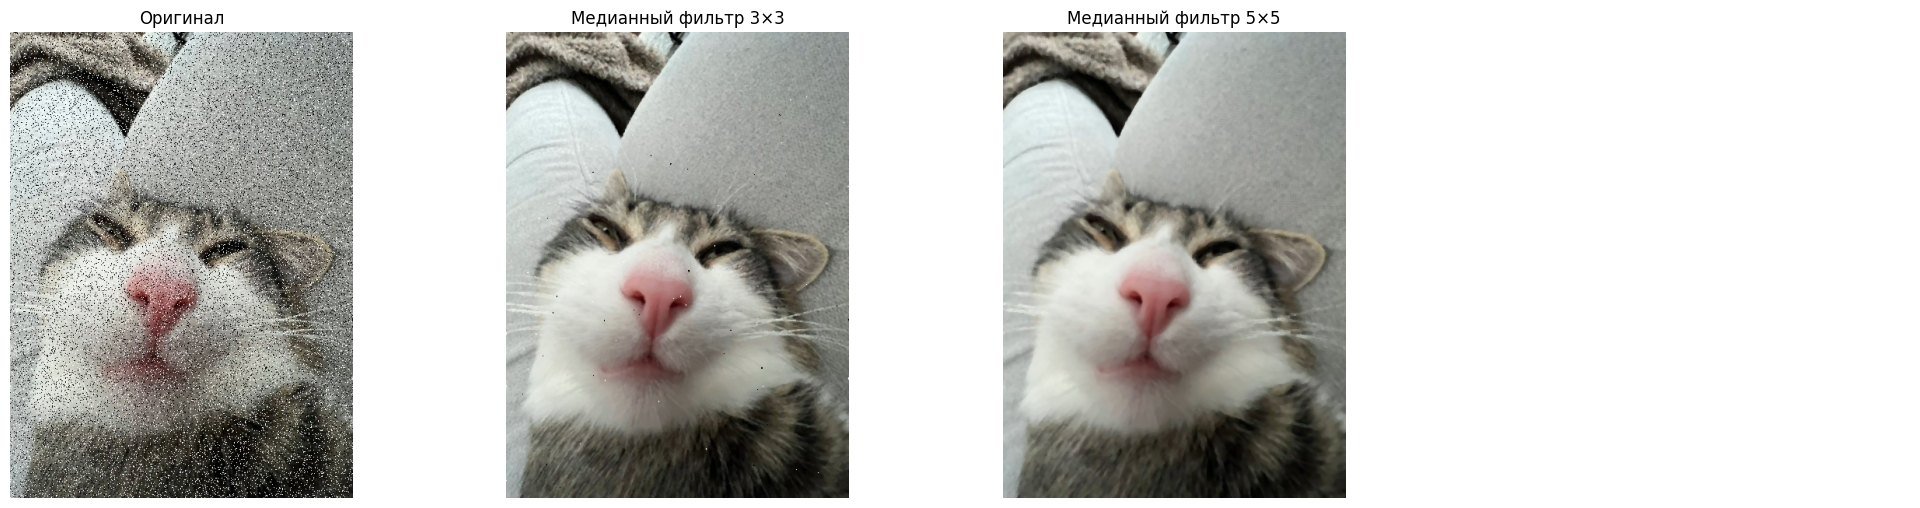

In [6]:
plt.figure(figsize=(20, 10))

# Верхний ряд изображений
plt.subplot(2, 4, 1)
plt.imshow(image_noize)
plt.title("Оригинал")
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(image_blur3)
plt.title("Медианный фильтр 3×3")
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(image_blur5)
plt.title("Медианный фильтр 5×5")
plt.axis('off')

plt.subplot(2, 4, 4)
plt.axis('off')

plt.tight_layout()
plt.show()


## 1.2 Фильтр гаусса

## Параметры

In [7]:
ksize1 = 7   
sigma1 = 1          

ksize2 = 7   
sigma2 = 1.4 

## Ядро Гаусса

In [8]:
def gaussian_kernel(size, sigma): # size ядра может быть только нечетным
    kernel = np.zeros((size, size)) # создаем двумерный массив size × size, заполненный нулями.
    # в него будут записываться значения Гауссовского ядра
    center = size // 2 # индекс центра ядра
    # для size = 5 центр - это индекс 2 (строка/столбец с номером 2), он будет использоваться как точка (0,0) в формуле
    
    #  Формула Гауссианы: G(x,y) = 1/(2πσ²) × exp(-(x²+y²)/(2σ²))
    norm_factor = 1.0 / (2 * np.pi * sigma**2)
    
    for i in range(size):
        for j in range(size): # двойной цикл по всем индексам ядра
            x, y = i - center, j - center # координаты точки относительно центра ядра, так мы подставляем в формулу расстояние от центра
            
            # Теоретически правильная формула (сумма ≈ 1)
            kernel[i, j] = norm_factor * np.exp(-(x**2 + y**2) / (2 * sigma**2)) # считается значение Гаусса в точке (x,y)
    
    return kernel

## Фильтр Гаусса

In [9]:
def gaussian_filter(img, kernel_size=7, sigma=1.0): # дисперсия - sigma
    kernel = gaussian_kernel(kernel_size, sigma) # создаем 2D‑гауссово ядро свёртки размера kernel_size × kernel_size с параметром sigma
    pad_h, pad_w = kernel_size // 2, kernel_size // 2 # сколько пикселей нужно дополнить (padding) сверху/снизу и слева/справа (при kernel_size=7 pad_h = pad_w = 3, чтобы окно 7×7 помещалось около границ)
    rows, cols, channels = img.shape # сохраняем размеры изображения
    
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='edge')
    # дополняем изображение по краям, чтобы можно было применять ядро и к граничным пикселям
    result = np.zeros_like(img)
    # создаем пустой выходной массив того же размера и типа, что img, сначала заполненный нулями
    
    for i in range(rows): # двойной цикл по всем координатам пикселя 
        for j in range(cols):
            window = padded[i:i+kernel_size, j:j+kernel_size] # окно размером kernel_size × kernel_size из дополненного изображения, соответствующее пикселю (i, j)
            for c in range(channels): # по каналам
                result[i, j, c] = np.sum(window[:, :, c] * kernel)
    # берем канал c в окне (window[:, :, c]), поэлементно умножаем на гауссово ядро и суммируем.
    # это и есть дискретная свёртка: новая интенсивность пикселя (i, j, c) — взвешенная сумма соседей.
    return np.clip(result, 0, 255).astype(np.uint8)
    # обрезаем значения к диапазону , чтобы не было переполнения/отрицательных значений, затем переводим в тип uint8, стандартный для изображений


## Загрузка изображения

In [10]:
img_bgr = cv2.imread('cat.jfif')
if img_bgr is None:
    print("Не удалось загрузить изображение")

## Применение

In [11]:
kernel1 = gaussian_kernel(ksize1, sigma1)
kernel2 = gaussian_kernel(ksize2, sigma2)
img1 = gaussian_filter(img_bgr, ksize1, sigma1)
img2 = gaussian_filter(img_bgr, ksize2, sigma2)

## Визуализация

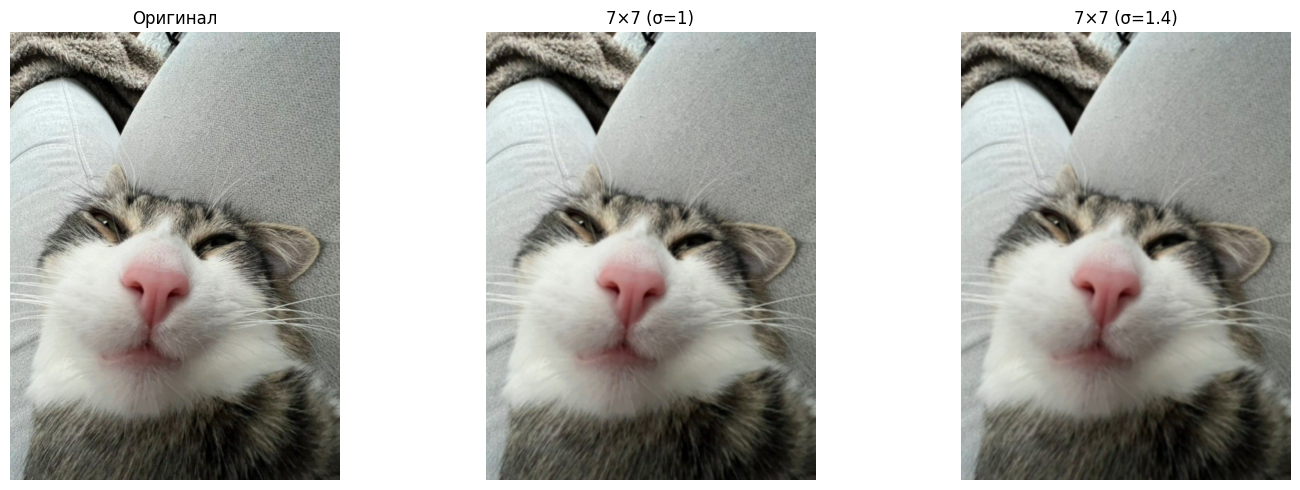

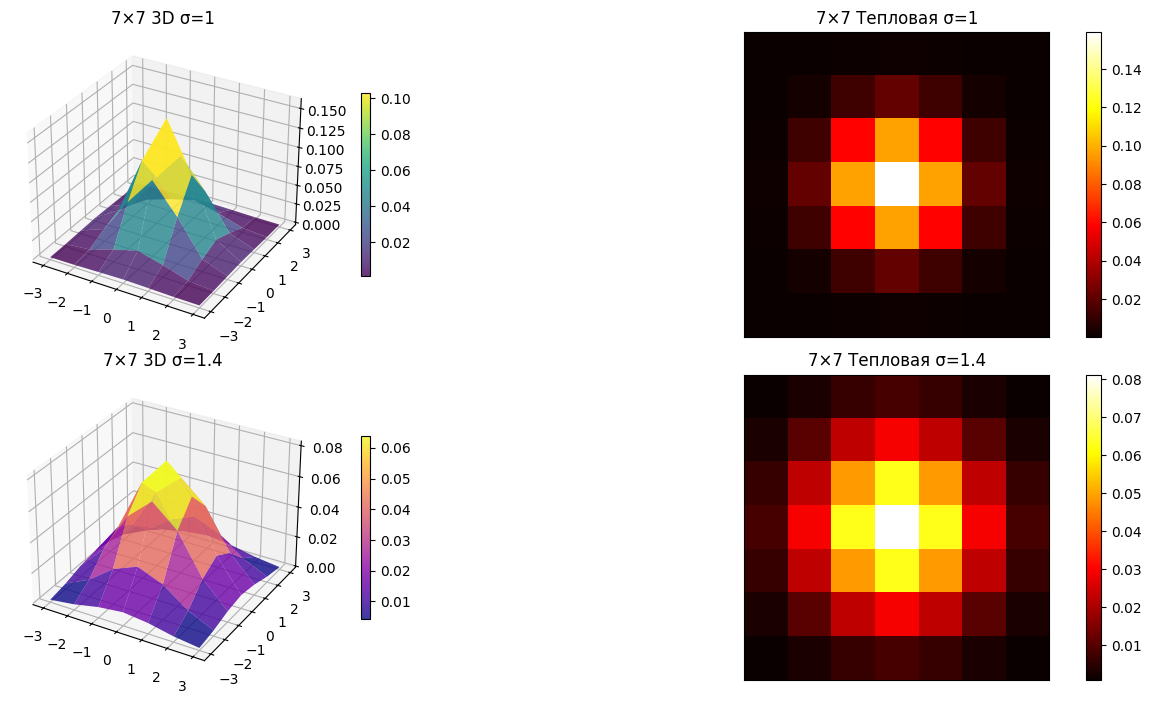

Ядро 7×7 (σ=1):
[[0.    0.    0.001 0.002 0.001 0.    0.   ]
 [0.    0.003 0.013 0.022 0.013 0.003 0.   ]
 [0.001 0.013 0.059 0.097 0.059 0.013 0.001]
 [0.002 0.022 0.097 0.159 0.097 0.022 0.002]
 [0.001 0.013 0.059 0.097 0.059 0.013 0.001]
 [0.    0.003 0.013 0.022 0.013 0.003 0.   ]
 [0.    0.    0.001 0.002 0.001 0.    0.   ]]
Сумма: 0.999459

Ядро 7×7 (σ=1.4):
[[0.001 0.003 0.006 0.008 0.006 0.003 0.001]
 [0.003 0.011 0.023 0.029 0.023 0.011 0.003]
 [0.006 0.023 0.049 0.063 0.049 0.023 0.006]
 [0.008 0.029 0.063 0.081 0.063 0.029 0.008]
 [0.006 0.023 0.049 0.063 0.049 0.023 0.006]
 [0.003 0.011 0.023 0.029 0.023 0.011 0.003]
 [0.001 0.003 0.006 0.008 0.006 0.003 0.001]]
Сумма: 0.978815


In [12]:
# Визуализация
img_rgb = bgr2rgb(img_bgr)
img1_rgb = bgr2rgb(img1)
img2_rgb = bgr2rgb(img2)

plt.figure(figsize=(15, 5))
plt.subplot(131); plt.imshow(img_rgb); plt.title("Оригинал"); plt.axis('off')
plt.subplot(132); plt.imshow(img1_rgb); plt.title(f"{ksize1}×{ksize1} (σ={sigma1})"); plt.axis('off')
plt.subplot(133); plt.imshow(img2_rgb); plt.title(f"{ksize2}×{ksize2} (σ={sigma2})"); plt.axis('off')
plt.tight_layout(); plt.show()

# Тепловые карты 
fig = plt.figure(figsize=(16, 7))

def kernel_grid(size):
    coords = np.arange(size) - (size-1)//2
    return np.meshgrid(coords, coords)

X1, Y1 = kernel_grid(ksize1)
ax1 = fig.add_subplot(221, projection='3d')
surf1 = ax1.plot_surface(X1, Y1, kernel1, cmap='viridis', alpha=0.8)
ax1.set_title(f'{ksize1}×{ksize1} 3D σ={sigma1}')
fig.colorbar(surf1, ax=ax1, shrink=0.6)

ax2 = fig.add_subplot(222)
im2 = ax2.imshow(kernel1, cmap='hot', interpolation='none')
ax2.set_title(f'{ksize1}×{ksize1} Тепловая σ={sigma1}')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
ax2.set_xticks([]); ax2.set_yticks([])

X2, Y2 = kernel_grid(ksize2)
ax3 = fig.add_subplot(223, projection='3d')
surf2 = ax3.plot_surface(X2, Y2, kernel2, cmap='plasma', alpha=0.8)
ax3.set_title(f'{ksize2}×{ksize2} 3D σ={sigma2}')
fig.colorbar(surf2, ax=ax3, shrink=0.6)

ax4 = fig.add_subplot(224)
im4 = ax4.imshow(kernel2, cmap='hot', interpolation='none')
ax4.set_title(f'{ksize2}×{ksize2} Тепловая σ={sigma2}')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
ax4.set_xticks([]); ax4.set_yticks([])

plt.tight_layout()
plt.show()

# Анализ ядер
print(f"Ядро {ksize1}×{ksize1} (σ={sigma1}):")
print(np.round(kernel1, 3))
print(f"Сумма: {kernel1.sum():.6f}")
print(f"\nЯдро {ksize2}×{ksize2} (σ={sigma2}):")
print(np.round(kernel2, 3))
print(f"Сумма: {kernel2.sum():.6f}")

# 2. Морфологические операции

## Преобразование BGR => GRAY

In [13]:
def rgb_to_gray(img):
    b, g, r = img[:,:,0], img[:,:,1], img[:,:,2] # разделяем каналы изображения
    gray = 0.299 * r + 0.587 * g + 0.114 * b # считаем яркость (люминанс) как взвешенную сумму каналов
    return gray.astype(np.uint8)
    # преобразуем результат к типу uint8 (целые 0–255), чтобы получить стандартное 8‑битное grayscale‑изображение, и возвращаем его

## Бинарное преобразование

In [14]:
def binarize(img_gray, threshold=150): #  принимаем img_gray — одноканальное (grayscale) изображение как массив H×W
    binary = np.zeros_like(img_gray)
    # новый массив того же размера и типа, как img_gray, заполненный нулями
    # на изображении это значит: пока все пиксели - чёрные (значение 0)
    binary[img_gray >= threshold] = 255 # булевая индексация, выражение img_gray>=threshold даёт булеву маску True/False такого же размера, как изображение
    # для всех пикселей, где условие True (яркость ≥ порога), в массиве binary записывается значение 255 (белый)
    # в итоге пиксели>=threshold становятся 255, все остальные остаются 0
    return binary.astype(np.uint8)

## 2.1 Эрозия

In [15]:
def erosion_manual(img, kernel_size=5): #  принимает бинарное (0/255) изображение img и размер структурирующего элемента kernel_size (SE), 
    # по умолчанию 5×5
    pad = kernel_size // 2
    rows, cols = img.shape # берем размеры входного изображения
    padded = np.pad(img, ((pad, pad), (pad, pad)), mode='constant') # дополняем изображение нулями по краям
    # добавляем pad строк сверху и снизу, pad столбцов слева и справа
    # mode='constant' (по умолчанию значение 0) - за пределами изображения считаем фон чёрным (0)
    result = np.zeros((rows, cols), dtype=np.uint8) # создаем выходное изображение того же размера, все заполнено 0 (фон)
    
    # Стандартный квадратный SE = np.ones(квадратная матрица из единиц kernel_size × kernel_size), проверяем все пиксели окна одинаково
    for i in range(rows):
        for j in range(cols):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            # берем локальное окно из дополненного изображения размером kernel_size×kernel_size, соответствующее позиции (i, j) в исходном изображении
          
            if np.all(window == 255): # проверяет, что все пиксели окна белые
                result[i, j] = 255 # если так, устанавливаем текущий пиксель результата в 255 (белый)
                # если хотя бы один пиксель в окне черный (0), пиксель результата остаётся 0 (объект «съедается» по краю)
    
    return result # возвращаем эродированное бинарное изображение

## Применение

In [16]:
img_gray = rgb_to_gray(img_bgr)
img_binary = binarize(img_gray, threshold=150)
img_eroded = erosion_manual(img_binary, kernel_size=5)

## Визуализация

(np.float64(-0.5), np.float64(645.5), np.float64(876.5), np.float64(-0.5))

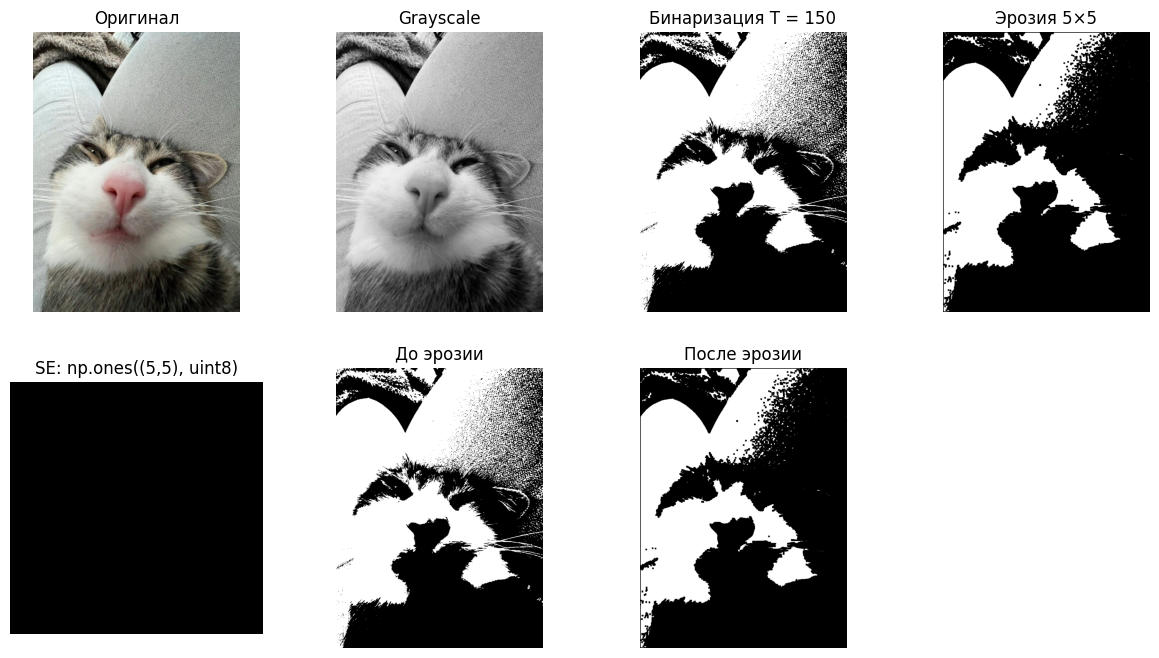

In [17]:
plt.figure(figsize=(15, 8))
# Изображения 1-4
plt.subplot(2, 4, 1)
plt.imshow(bgr2rgb(img_bgr))
plt.title("Оригинал")
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(img_binary, cmap='gray')
plt.title("Бинаризация T = 150")
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(img_eroded, cmap='gray')
plt.title("Эрозия 5×5")
plt.axis('off')

# Структурирующий элемент 
plt.subplot(2, 4, 5)
se_5x5 = np.ones((5,5), dtype=np.uint8)
plt.imshow(se_5x5, cmap='gray')
plt.title("SE: np.ones((5,5), uint8)")
plt.axis('off')

# Сравнение До и После
plt.subplot(2, 4, 6)
plt.imshow(img_binary, cmap='gray')
plt.title("До эрозии")
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(img_eroded, cmap='gray')
plt.title("После эрозии")
plt.axis('off')


## 2.2 Дилатация

In [18]:
def dilate(mask, kernel_size=(7,7), iterations=1):

    se = np.ones(kernel_size, dtype=np.uint8) # функция np.ones создает матрицу 7х7 размера, заполненную единицами
    # тип данных для элементов матрицы беззнаковое 8-битное целое число (значения от 0 до 255)
    result = mask.copy()
    # Создается независимая копия исходной маски. Это делается для того, чтобы не изменять оригинальное изображение mask в процессе работы

    for _ in range(iterations): # цикл, который повторится iterations раз
        # Переменная _ используется, когда нам не нужно знать номер текущей итерации, а важен только сам факт повторения
        se_size = se.shape[0] # Получается размер структурного элемента
        pad = se_size // 2 # Вычисляется величина отступа. Этот отступ необходим, чтобы обработать пиксели по краям изображения, не выходя за его границы
        rows, cols = result.shape # Получаются размеры текущего изображения result (количество строк и столбцов)
        
        padded = np.pad(result, ((pad, pad), (pad, pad)), mode='constant')
        # Функция np.pad добавляет рамку вокруг изображения result
        # (pad, pad) означает, что нужно добавить pad пикселей сверху и pad пикселей снизу. Второй - pad пикселей слева и pad пикселей справа
        # mode='constant' означает, что добавляемые пиксели будут заполнены константой. По умолчанию эта константа - 0 (черный цвет)
        new_result = np.zeros((rows, cols), dtype=np.uint8)
        # Создается новое пустое изображение (матрица), заполненное нулями, такого же размера (rows, cols), как и исходное. В него будут записываться результаты обработки для текущей итерации
        for i in range(rows): # Организуется перебор всех пикселей изображения
            for j in range(cols):
                window = padded[i:i+se_size, j:j+se_size]
    # Из расширенного изображения padded вырезается фрагмент (окно) размером se_size x se_size. Начало окна находится в точке с координатами (i, j) дополненного изображения. 
    # Благодаря тому, что мы добавили отступы pad, координаты i и j исходного изображения точно соответствуют позиции окна, которое накрывает соответствующий пиксель и его окрестность
                # Дилатация: если хоть один пиксель в окне = 255
                if np.max(window) == 255:
                    new_result[i, j] = 255
    # np.max(window) будет равен 255, если в этом окне есть хотя бы один белый пиксель (принадлежащий объекту). 
    # Если все пиксели в окне черные (0), то максимум будет равен 0
        result = new_result
    
    return result

## Применение

In [19]:
img_gray = rgb_to_gray(img_bgr)
mask = binarize(img_gray, threshold=150)
mask_dil = dilate(mask, kernel_size=(7,7), iterations=1)

## Визуализация

(np.float64(-0.5), np.float64(645.5), np.float64(876.5), np.float64(-0.5))

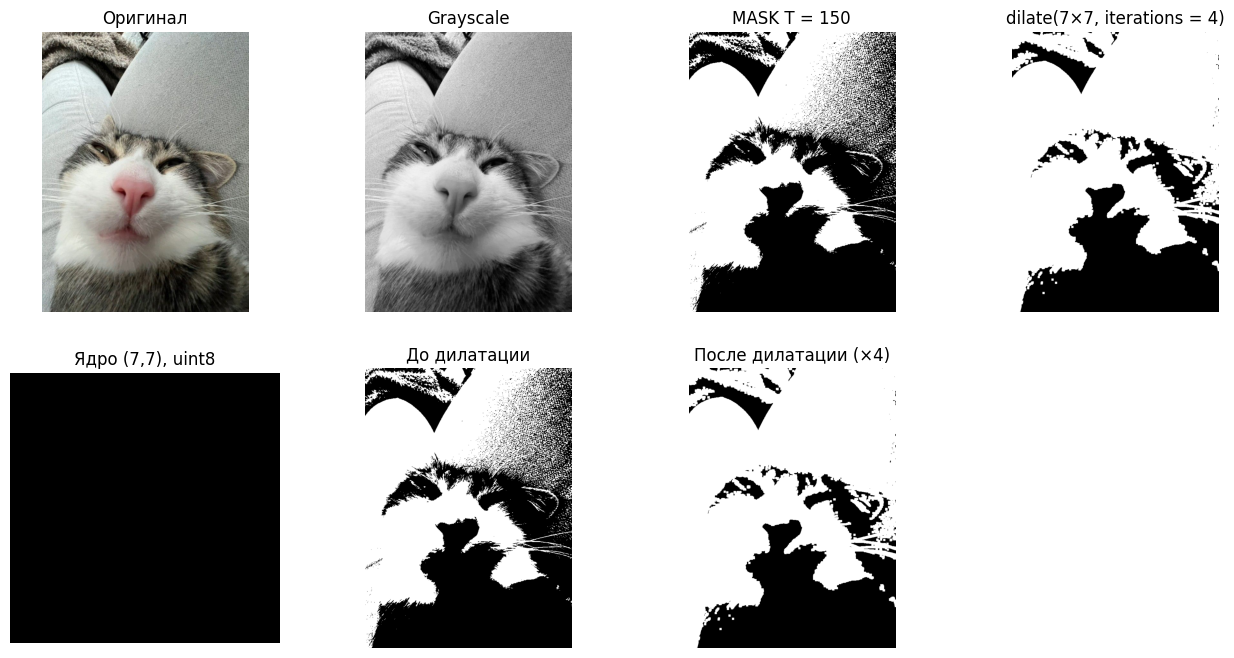

In [20]:
# Визуализация без гистограмм (2x4)
plt.figure(figsize=(16, 8))

# Этап 1-4
plt.subplot(2, 4, 1)
plt.imshow(bgr2rgb(img_bgr))
plt.title("Оригинал")
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(mask, cmap='gray')
plt.title("MASK T = 150")
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(mask_dil, cmap='gray')
plt.title("dilate(7×7, iterations = 4)")
plt.axis('off')

# Структурирующий элемент
plt.subplot(2, 4, 5)
kernel = np.ones((7,7), dtype=np.uint8)
plt.imshow(kernel, cmap='gray')
plt.title("Ядро (7,7), uint8")
plt.axis('off')

# Сравнение ДО/ПОСЛЕ
plt.subplot(2, 4, 6)
plt.imshow(mask, cmap='gray')
plt.title("До дилатации")
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(mask_dil, cmap='gray')
plt.title("После дилатации (×4)")
plt.axis('off')


# 3. Прочие операции

## Преобразование BGR => GRAY

In [21]:
def bgr2gray_manual(img):
    b, g, r = img[:,:,0], img[:,:,1], img[:,:,2]
    gray = 0.299 * r + 0.587 * g + 0.114 * b
    return gray.astype(np.uint8)

## Пороговая бинаризация

### Бинаризация grayscale

In [22]:
def binarize_grayscale(img_gray, threshold=150): # threshold=150 пиксели, яркость которых больше или равна этому значению, станут белыми, а все остальные черными
    binary = np.zeros_like(img_gray, dtype=np.uint8)
    binary[img_gray >= threshold] = 255 # создает булеву маску
    # сравнивает каждый пиксель в img_gray с пороговым значением threshold. Результатом является массив той же формы, состоящий из значений True и False. True ставится там, где пиксель исходного изображения больше или равен порогу (150), а False — где пиксель меньше порога
    return binary

### Бинаризация rgb

In [23]:
def binarize_rgb(img_rgb, threshold=150):
    mean_rgb = np.mean(img_rgb, axis=2).astype(np.uint8)
    # Функция np.mean вычисляет среднее арифметическое значение вдоль указанной оси
    # axis=2 означает, что усреднение происходит по третьему измерению (каналы RGB). 
    # Для каждого пикселя берется три значения (R, G, B) и вычисляется их среднее
    # Результат двумерный массив (высота, ширина), где каждый элемент представляет собой среднюю яркость соответствующего пикселя исходного цветного изображения
    binary = np.zeros((img_rgb.shape[0], img_rgb.shape[1]), dtype=np.uint8)
    # Создает массив, заполненный нулями, размером (img_rgb.shape[0], img_rgb.shape[1]), высота и ширина исход. изобр.
    # создается двумерный массив точно такого же пространственного размера, как и исходное цветное изображение
    binary[mean_rgb >= threshold] = 255
    return binary

### Бинаризация по каждому каналу rgb

In [24]:
def binarize_rgb_channels(img_rgb, thresholds=(150, 150, 150)):
    r_bin = (img_rgb[:,:,0] >= thresholds[0]).astype(np.uint8) * 255
    # Извлекается красный канал изображения (все строки :, все столбцы :, первый канал с индексом 0). 
    #Результат — двумерный массив с яркостями красного компонента для каждого пикселя. Сравнение каждого пикселя красного канала с пороговым значением для красного канала
    # Преобразование булевой маски в числа: True становится 1, False становится 0
    # * 255 преобразует единицы в 255 (белый цвет), а нули остаются нулями (черный цвет)
    g_bin = (img_rgb[:,:,1] >= thresholds[1]).astype(np.uint8) * 255  
    b_bin = (img_rgb[:,:,2] >= thresholds[2]).astype(np.uint8) * 255
    return r_bin, g_bin, b_bin

### Применение

In [25]:
img_bgr = cv2.imread("cat.jfif")
img_rgb = bgr2rgb(img_bgr)          # цветное, 3 канала

img_gray = bgr2gray_manual(img_bgr) # ЧБ, 1 канал

# Только нужные бинаризации
gray_bin_150 = binarize_grayscale(img_gray, 150)  # Только T = 150
rgb_bin_mean = binarize_rgb(img_rgb, 150)
r_bin, g_bin, b_bin = binarize_rgb_channels(img_rgb, (150, 150, 150))

### Визуализация

(np.float64(-0.5), np.float64(645.5), np.float64(876.5), np.float64(-0.5))

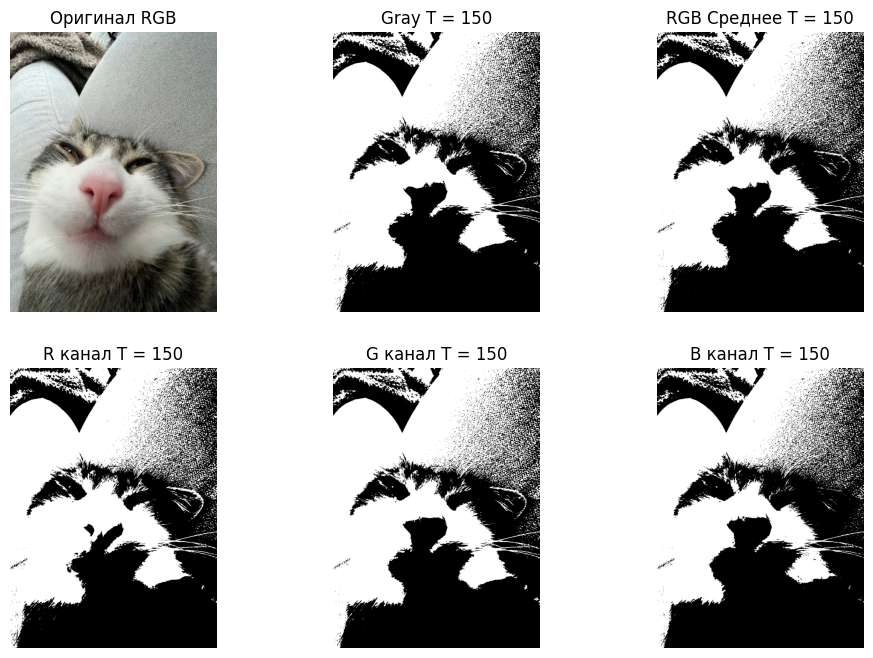

In [26]:
plt.figure(figsize=(16, 8))
plt.subplot(2, 4, 1)
plt.imshow(img_rgb)
plt.title("Оригинал RGB")
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(gray_bin_150, cmap='gray')
plt.title("Gray T = 150")
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(rgb_bin_mean, cmap='gray')
plt.title("RGB Среднее T = 150")
plt.axis('off')

# Каналы RGB
plt.subplot(2, 4, 5)
plt.imshow(r_bin, cmap='gray')
plt.title("R канал T = 150")
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(g_bin, cmap='gray')
plt.title("G канал T = 150")
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(b_bin, cmap='gray')
plt.title("B канал T = 150")
plt.axis('off')

## Выравнивание гистограмм

In [27]:
def histogram_equalization(img_gray):
    rows, cols = img_gray.shape # Получаем размеры изображения: количество строк (высоту) и столбцов (ширину)
    L = 256 # Определяем количество возможных уровней яркости. Для 8-битного изображения это 256 (от 0 до 255)
    
    # Гистограмма
    hist = np.zeros(L, dtype=np.int32)
    # Создаем массив для гистограммы размером L, заполненный нулями. Каждый элемент будет хранить количество пикселей с соответствующей яркостью. 
    # Тип np.int32 выбран для предотвращения переполнения при подсчете большого количества пикселей
    for i in range(rows): # Проходим по всем пикселям изображения
        for j in range(cols):
            hist[img_gray[i,j]] += 1 # Для каждого пикселя берем его значение яркости (от 0 до 255) и увеличиваем соответствующий элемент гистограммы на 1
    
    # Кумулятивная функция распределения (CDF)
    cdf = hist.cumsum() # Метод .cumsum() вычисляет накопленную сумму элементов массива hist. 
    # Например, cdf[k] будет содержать общее количество пикселей с яркостью от 0 до k включительно
    cdf_normalized = cdf * (L - 1) / (rows * cols) # Формула преобразует накопленные частоты в новые значения яркости
    cdf_normalized = cdf_normalized.astype(np.uint8) # Преобразуем полученные значения в тип uint8
    
    # Маппинг
    result = np.zeros_like(img_gray) # Создаем пустой массив такого же размера, как исходное изображение, для хранения результата
    for i in range(rows):
        for j in range(cols):
            old_intensity = img_gray[i,j] # Получаем исходную яркость текущего пикселя
            result[i,j] = cdf_normalized[old_intensity]
    # Используем исходную яркость как индекс в массиве cdf_normalized, чтобы получить новое значение яркости для этого пикселя 
    # каждое исходное значение яркости заменяется соответствующим значением из нормализованной CDF
    
    return result, hist, cdf
    # result изображение после эквализации гистограммы
    # hist исходная гистограмма (для анализа)
    # cdf исходная кумулятивная функция распределения (для анализа)


### Загрузка изображения

In [28]:
img_bgr = cv2.imread('flowers.jpg')

### Применение

In [29]:
img_gray = bgr2gray_manual(img_bgr)
img_eq, hist_original, cdf_original = histogram_equalization(img_gray)

# Гистограмма и CDF для ПОСЛЕ улучшения качества
hist_eq = np.bincount(img_eq.ravel(), minlength=256)
cdf_eq = hist_eq.cumsum()

### Визуализация

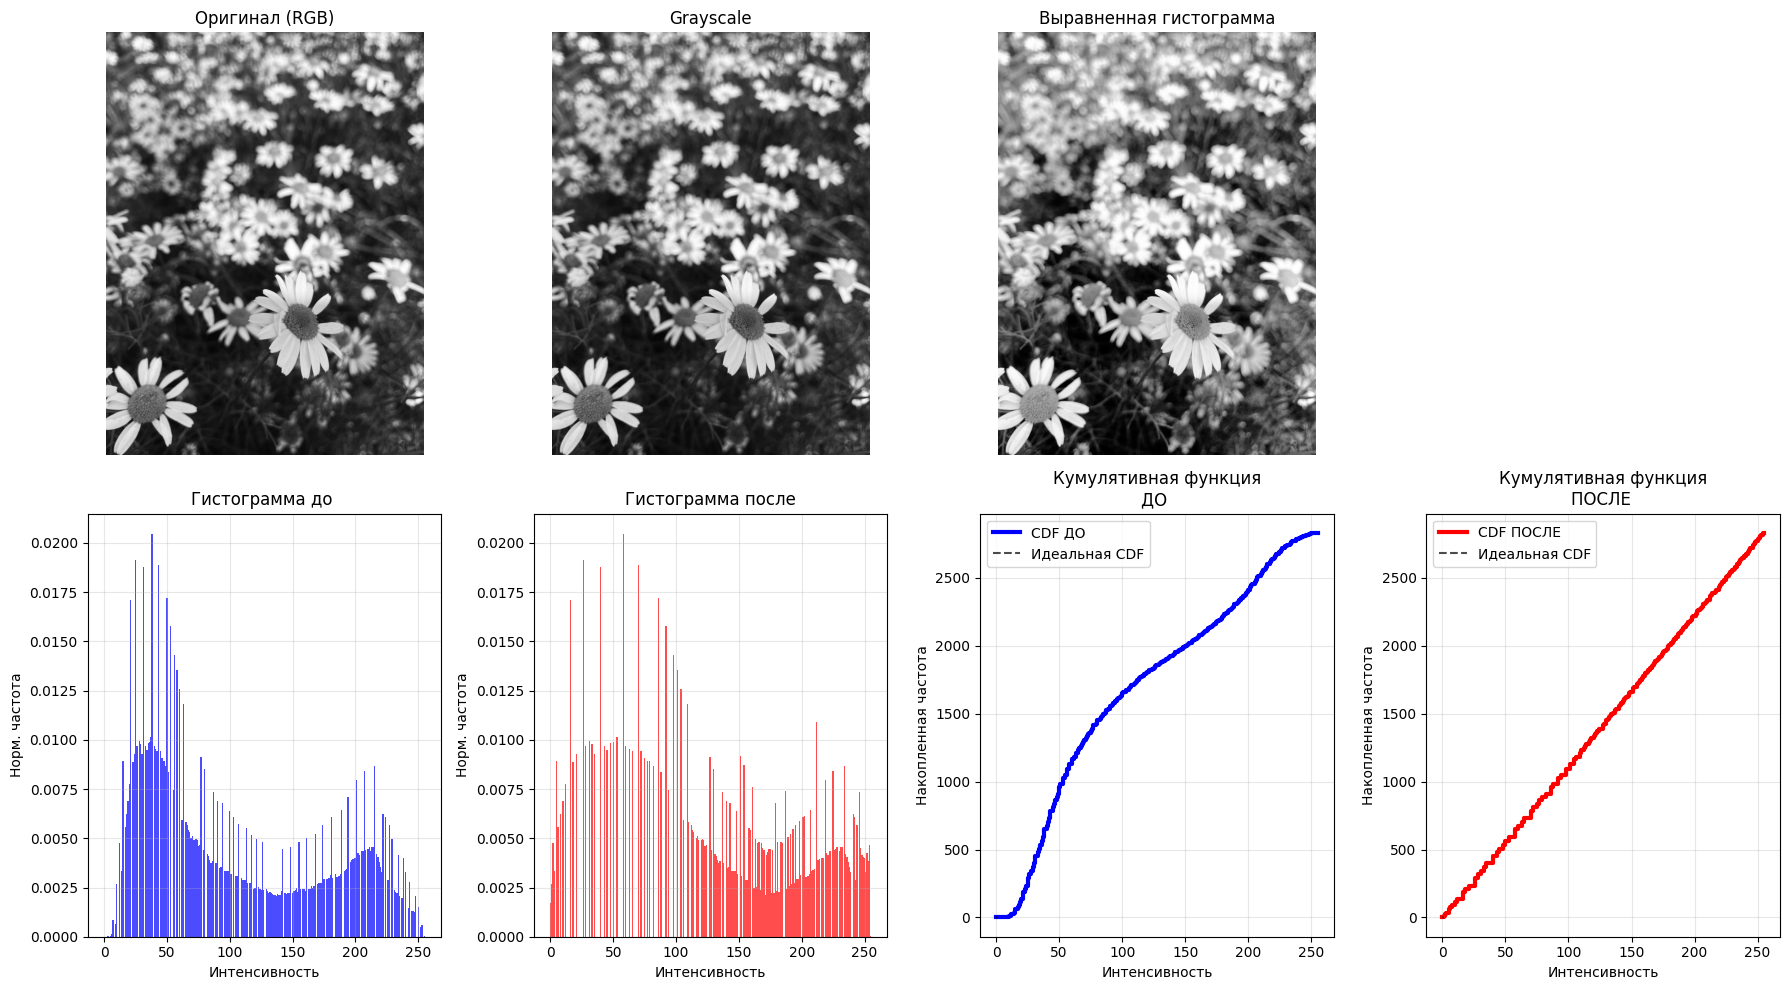

In [30]:
# Визуализация (2x4)
plt.figure(figsize=(18, 10))

# Изображения
plt.subplot(2, 4, 1)
plt.imshow(bgr2rgb(img_bgr))
plt.title("Оригинал (RGB)")
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(img_eq, cmap='gray')
plt.title("Выравненная гистограмма")
plt.axis('off')

# ГИСТОГРАММЫ ОТДЕЛЬНО
plt.subplot(2, 4, 5)
bins = np.arange(256)
plt.bar(bins, hist_original/img_gray.size, alpha=0.7, color='blue', width=1)
plt.title("Гистограмма до ")
plt.xlabel("Интенсивность")
plt.ylabel("Норм. частота")
plt.grid(True, alpha=0.3)

plt.subplot(2, 4, 6)
plt.bar(bins, hist_eq/img_eq.size, alpha=0.7, color='red', width=1)
plt.title("Гистограмма после")
plt.xlabel("Интенсивность")
plt.ylabel("Норм. частота")
plt.grid(True, alpha=0.3)

# CDF отдельно до
plt.subplot(2, 4, 7)
plt.plot(bins[:len(cdf_original)], cdf_original/255, 'b-', linewidth=3, 
         drawstyle='steps-post', label='CDF ДО')
plt.plot([0,1], [0,1], 'k--', alpha=0.7, label='Идеальная CDF')
plt.title("Кумулятивная функция\nДО ")
plt.xlabel("Интенсивность")
plt.ylabel("Накопленная частота")
plt.legend()
plt.grid(True, alpha=0.3)

# CDF отдельно после
plt.subplot(2, 4, 8)
plt.plot(bins[:len(cdf_eq)], cdf_eq/255, 'r-', linewidth=3, 
         drawstyle='steps-post', label='CDF ПОСЛЕ')
plt.plot([0,1], [0,1], 'k--', alpha=0.7, label='Идеальная CDF')
plt.title("Кумулятивная функция\nПОСЛЕ ")
plt.xlabel("Интенсивность")
plt.ylabel("Накопленная частота")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Поворот изображений

### Поворот на 90

In [31]:
def rotate_90(image):
    return np.rot90(image, k=-1)

### Поворот на 180

In [32]:
def rotate_180(image):
    return np.rot90(image, k=2)

### Поворот на 270

In [33]:
def rotate_270(image):
    return np.rot90(image, k=1)

### Загрузка изображения

In [34]:
img_bgr1 = cv2.imread('cat.jfif')

### Применение

In [35]:
img_rgb = bgr2rgb(img_bgr1)

img_90 = rotate_90(img_rgb)
img_180 = rotate_180(img_rgb)
img_270 = rotate_270(img_rgb)

### Визуализация

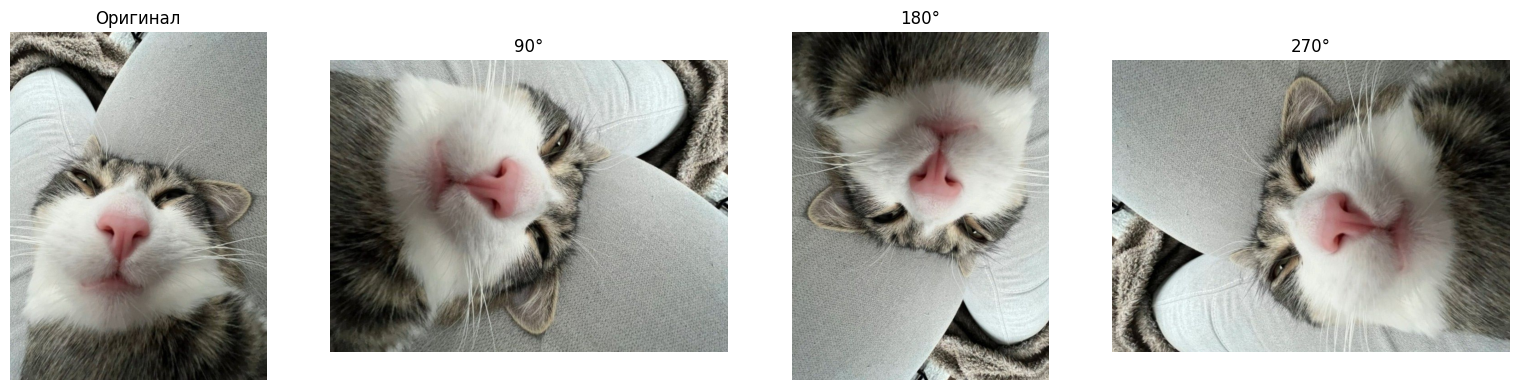

In [36]:
# Визуализация (только цветные повороты, 1x4)
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title("Оригинал")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_90)
plt.title("90°")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_180)
plt.title("180°")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_270)
plt.title("270°")
plt.axis('off')

plt.tight_layout()
plt.show()
